### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from whale_gunshot_localization import config
from whale_gunshot_localization.utils.experimental import WAVReader
from whale_gunshot_localization.utils.transformations import to_spect

### Helper Functions

In [2]:
def convert_range(old_range, new_range, old_value):
    """
    Linearly map a number from one range to another range.

    Parameters
    ----------
    old_range : array-like, shape: 1 X 2
        minimum and maximum of the old number range
    new_range : array-like, shape: 1 X 2
        minimum and maximum of the new number range
    old_value : float
        value to map onto new range
    
    Returns
    -------
    : float
        value mappend onto new range
    """

    old_diff = (old_range[1] - old_range[0])  
    new_diff = (new_range[1] - new_range[0])  
    return (((old_value - old_range[0]) * new_diff) / old_diff) + new_range[0]

### Search Data

2022-05-21T05:11:23 2022-05-25T12:56:11
2022-05-21T04:34:59 2022-05-25T17:23:21
2022-05-21T04:21:46 2022-05-25T17:05:13
2022-05-21T05:48:08 2022-05-25T14:39:42
2022-05-21T06:04:25 2022-05-25T14:20:38
2022-05-21T02:34:21 2022-05-25T12:08:40
2022-05-21T02:18:02 2022-05-25T11:49:56
2022-05-21T03:38:09 2022-05-25T16:16:35
2022-05-21T03:56:36 2022-05-25T16:41:42
2022-05-21T06:45:13 2022-05-25T13:41:57
2022-05-21T06:29:22 2022-05-25T13:55:40
2022-05-21T01:43:03 2022-05-25T11:01:53
2022-05-21T00:53:35 2022-05-25T10:44:17
2022-05-21T05:30:14 2022-05-25T15:07:10
2022-05-21T04:52:19 2022-05-25T17:46:49
2022-05-21T03:07:33 2022-05-25T12:30:31
2022-05-21T07:10:13 2022-05-25T13:17:52
True
(17, 18000)
['/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5483/5483.220523170937.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6464/6464.220523163331.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6466/6466.220523162032.wav'
 '/media/mark/extradrive2/SBCE

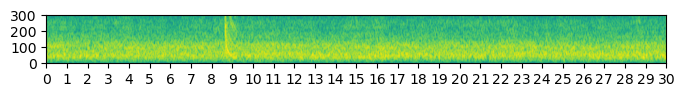

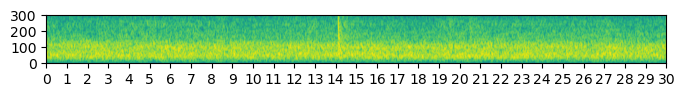

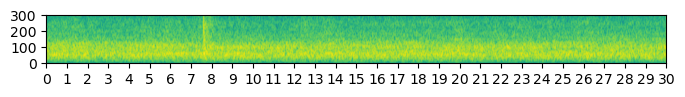

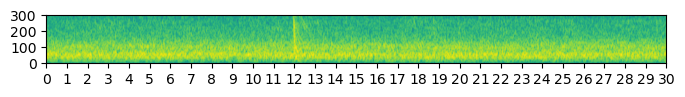

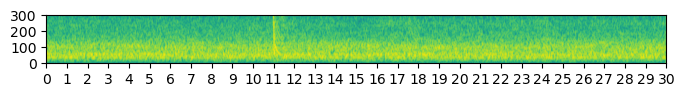

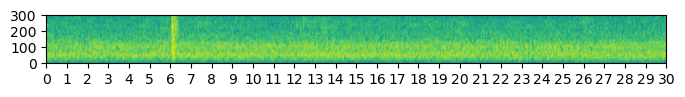

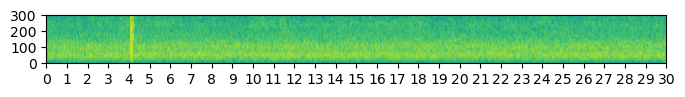

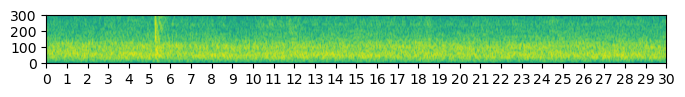

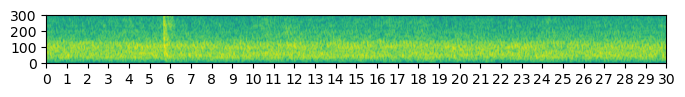

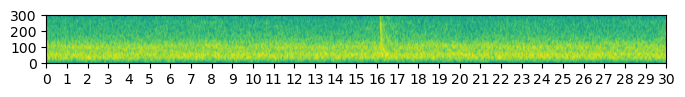

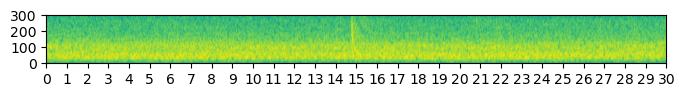

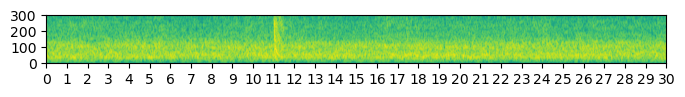

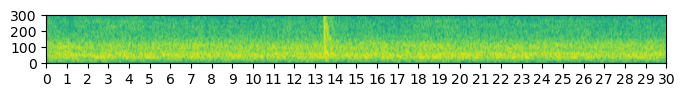

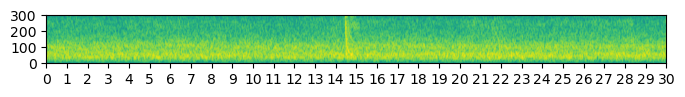

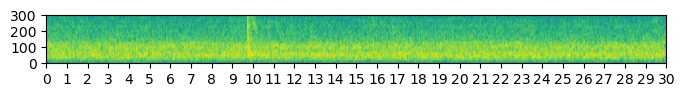

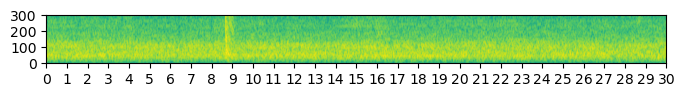

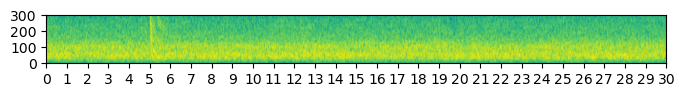

In [3]:
## Settings
chunk_size = 30
timestamp = '2022-05-23T23:39:15' # from 2022-05-21T07:10:13 to 2022-05-25T17:46:49

# object to read timestamp from WAV file
WR = WAVReader(sensors=config['TOSSIT']['ids'], chunk_size=chunk_size, fs_desired=config['signal']['fs'])

success, file_list, data, file_times = WR.get_audio(timestamp=np.datetime64(timestamp))
print(success)
print(data.shape)
print(file_list)
print(file_times)

for i in range(data.shape[0]):
    fig = plt.figure()
    ax2 = fig.gca()
    spect = to_spect(data[i,...] - data[i,...].mean()).squeeze()
    ax2.imshow(spect)

    # set x ticks
    x_tick_labels = np.arange(0, chunk_size + 1, 1)
    old_range_x = [0, chunk_size]
    new_range_x = [0, spect.shape[1]]
    ax2.set_xticks([convert_range(old_range_x, new_range_x, val) for val in x_tick_labels])
    ax2.set_xticklabels([int(val) if val.is_integer() else val for val in x_tick_labels])

    # set y ticks
    y_tick_labels = np.arange(0, config['signal']['fs'] / 2 + 1, 100)
    old_range_y = [0, config['signal']['fs'] / 2]
    new_range_y = [0, spect.shape[0]]
    ax2.set_yticks([convert_range(old_range_y, new_range_y, val) for val in y_tick_labels])
    ax2.set_yticklabels(reversed([int(val) if val.is_integer() else val for val in y_tick_labels]))